In [67]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

df = pl.scan_parquet("out/*.parquet", missing_columns='insert', extra_columns="ignore").collect().cast({
    "compression_time" : pl.Duration('ns'),
    "decompression_time" : pl.Duration('ns'),
})

In [68]:
df1 = df.select(
    ["trace", "alg", "clevel", "compressed_size", "compression_time", "decompression_time"]
).group_by(
    ["trace", "alg", "clevel"]
).mean()

In [69]:
df2 = df1.filter([
    pl.col("trace") == "spec-all",
    pl.col("alg") == "zlib",
]).sort(
    "clevel"
).with_columns(
    (4096 / pl.col("compressed_size")).alias("ratio"),
    ((4096e3) / pl.col("compression_time").dt.total_nanoseconds()).alias("rate")
)

df3 = df1.with_columns(
    (4096 / pl.col("compressed_size")).alias("ratio"),
    ((4096e3) / pl.col("compression_time").dt.total_nanoseconds()).alias("rate")
)

df3

trace,alg,clevel,compressed_size,compression_time,decompression_time,ratio,rate
str,str,i32,f64,duration[ns],duration[ns],f64,f64
"""spec-all""","""zstd""",8,1283.13628,1315431ns,12241ns,3.192178,3.113808
"""work-medium""","""zlib""",2,852.562983,132243ns,20431ns,4.804337,30.973284
"""spec-all""","""zstd""",7,1288.956532,705691ns,12402ns,3.177764,5.80424
"""build-llvm""","""lz4""",2,4027.116989,11012ns,1589ns,1.017105,371.957864
"""work-medium""","""lz4""",2,4078.910214,7618ns,1586ns,1.00419,537.67393
…,…,…,…,…,…,…,…
"""work-small""","""lz4""",3,3931.586057,9385ns,1584ns,1.041819,436.441129
"""work-medium""","""lz4""",3,4078.910214,7654ns,1567ns,1.00419,535.145022
"""build-llvm""","""lz4""",7,4027.116989,10800ns,1526ns,1.017105,379.259259


In [74]:
df3.filter(
    pl.col("trace") == "spec-all",
    pl.col("alg") == "zstd"
).sort("clevel")

trace,alg,clevel,compressed_size,compression_time,decompression_time,ratio,rate
str,str,i32,f64,duration[ns],duration[ns],f64,f64
"""spec-all""","""zstd""",1,1399.308069,28506ns,10991ns,2.927161,143.689048
"""spec-all""","""zstd""",2,1399.308069,28523ns,11193ns,2.927161,143.603408
"""spec-all""","""zstd""",3,1351.366352,65342ns,10978ns,3.031006,62.685562
"""spec-all""","""zstd""",4,1341.876454,104397ns,10671ns,3.052442,39.234844
"""spec-all""","""zstd""",5,1342.252235,166461ns,10873ns,3.051587,24.606364
"""spec-all""","""zstd""",6,1291.686176,493639ns,12068ns,3.171049,8.297562
"""spec-all""","""zstd""",7,1288.956532,705691ns,12402ns,3.177764,5.80424
"""spec-all""","""zstd""",8,1283.13628,1315431ns,12241ns,3.192178,3.113808
"""spec-all""","""zstd""",9,1283.082527,1437610ns,12421ns,3.192312,2.849173


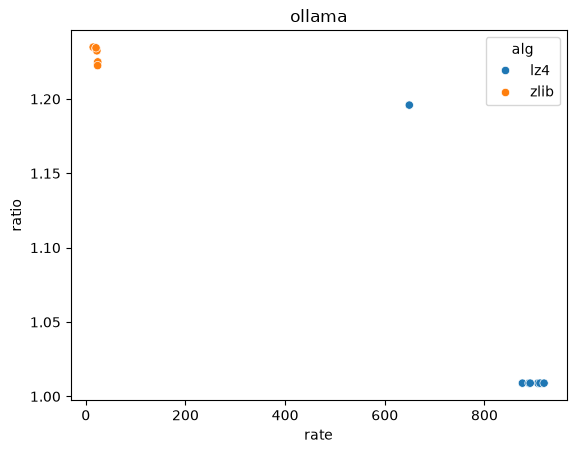

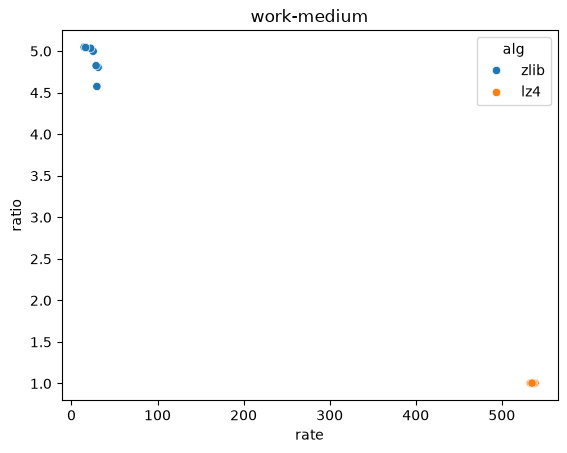

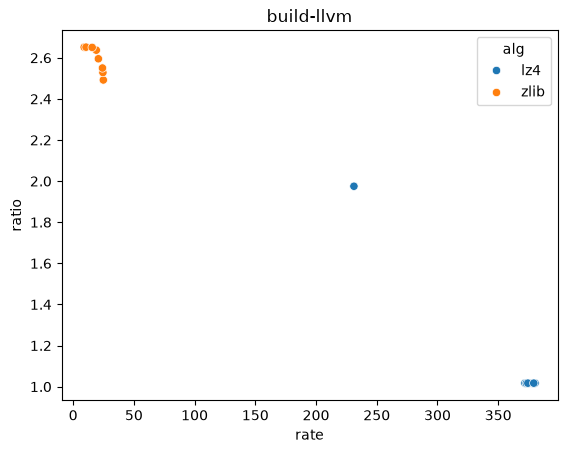

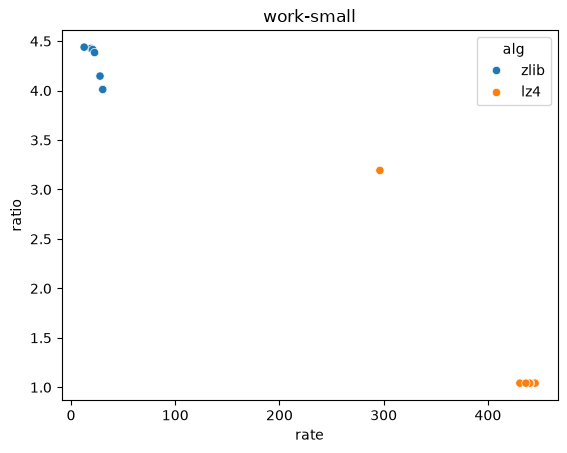

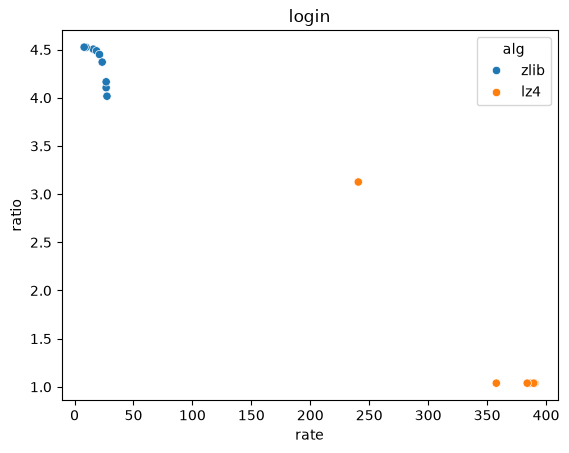

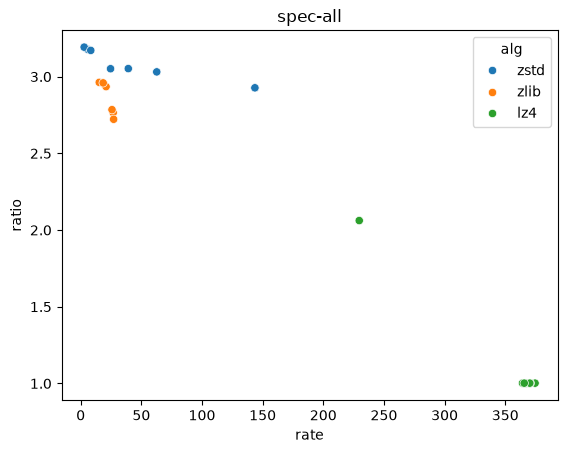

In [71]:
for trace in df["trace"].unique().to_list():
    df4 = df3.filter(pl.col("trace") == trace)

    plt.figure()
    sns.scatterplot(
        df4,
        x="rate",
        y="ratio",
        hue="alg"
    )
    plt.title(f"{trace}")

In [72]:
df1 = df.filter(
    pl.col("alg") == "zlib"
)

print(df1.group_by("clevel").mean().select(["clevel", "compressed_size", "compression_time", "decompression_time"]))

shape: (9, 4)
┌────────┬─────────────────┬──────────────────┬────────────────────┐
│ clevel ┆ compressed_size ┆ compression_time ┆ decompression_time │
│ ---    ┆ ---             ┆ ---              ┆ ---                │
│ i32    ┆ f64             ┆ duration[ns]     ┆ duration[ns]       │
╞════════╪═════════════════╪══════════════════╪════════════════════╡
│ 3      ┆ 1608.964735     ┆ 167036ns         ┆ 30606ns            │
│ 6      ┆ 1561.807244     ┆ 214328ns         ┆ 31479ns            │
│ 9      ┆ 1592.92538      ┆ 424318ns         ┆ 35470ns            │
│ 1      ┆ 1645.481153     ┆ 162009ns         ┆ 31542ns            │
│ 4      ┆ 1601.769199     ┆ 194401ns         ┆ 35607ns            │
│ 7      ┆ 1548.205781     ┆ 254155ns         ┆ 34908ns            │
│ 8      ┆ 1570.947995     ┆ 372635ns         ┆ 34779ns            │
│ 5      ┆ 1555.916683     ┆ 210246ns         ┆ 34994ns            │
│ 2      ┆ 1625.317316     ┆ 163919ns         ┆ 30937ns            │
└────────┴──────────

KeyboardInterrupt: 

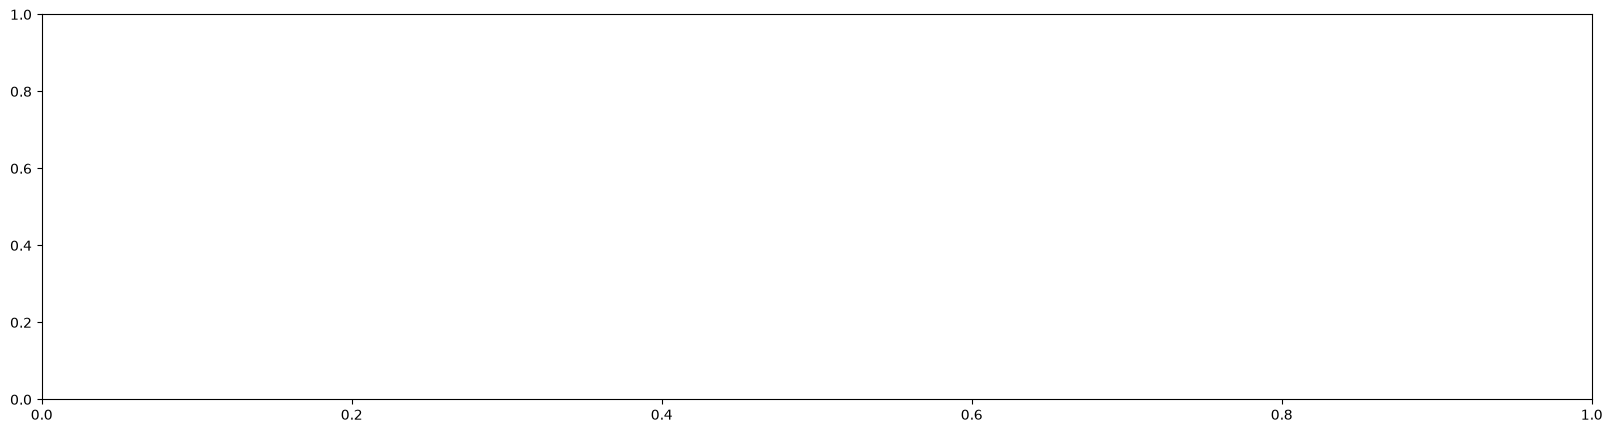

In [73]:

plt.figure(figsize=(20,5))
sns.lineplot(
    df1,
    x="page_number",
    y="compressed_size",
    hue="clevel"
)

plt.figure(figsize=(20,5))
sns.lineplot(
    df1,
    x="page_number",
    y="compression_time",
    hue="clevel"
)